In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'Arial'
sns.set_style("ticks")

In [2]:
import pickle as pkl

cluster_edges_path = '../cluster_edges/dyngen.pkl' # remember to change this
with open(cluster_edges_path, 'rb') as f:
    cluster_edges = pkl.load(f)
cluster_edges

[('sA->sB', 'sB->sBmid'),
 ('sB->sBmid', 'sBmid->sD'),
 ('sB->sBmid', 'sBmid->sC'),
 ('sBmid->sD', 'sD->sEndD'),
 ('sBmid->sC', 'sC->sEndC')]

In [3]:
import os

In [4]:
data_pair = ('simulate/batch', 'simulate/batch_scgen_cat')
basis = 'umap'
metric_name = 'time_score_edge'
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui']
results = {}
for cluster_edge in cluster_edges:
    edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
    result = {}
    for model in models:
        metrics = {}
        for data in data_pair:
            metric_file = f'../logs/{model}/{data}/metric_{basis}_redo.csv'
            if not os.path.exists(metric_file):
                metric_file = f'../logs/{model}/{data}/metric_{basis}.csv'
            metric = pd.read_csv(metric_file)
            metric.set_index('Unnamed: 0', inplace=True)
            idx_name = f'{metric_name}_pred_t_norm_{edge}'
            if idx_name in metric.index:
                t_score = metric.loc[metric.index == idx_name, '0'].values[0]
                t_score = float(t_score)
                metrics[data] = t_score
        result[model] = metrics
        if model == 'scvelo':
            scv_metrics = {}
            for data in data_pair:
                scv_metric_file = f'../logs/{model}/{data}/metric_{basis}_redo.csv'
                if not os.path.exists(scv_metric_file):
                    scv_metric_file = f'../logs/{model}/{data}/metric_{basis}.csv'
                scv_metric = pd.read_csv(scv_metric_file)
                scv_metric.set_index('Unnamed: 0', inplace=True)
                scv_idx_name = f'{metric_name}_fit_t_norm_{edge}'
                if scv_idx_name in scv_metric.index:
                    t_score = scv_metric.loc[scv_metric.index == scv_idx_name, '0'].values[0]
                    t_score = float(t_score)
                    scv_metrics[data] = t_score
            result['scvelo(avg)'] = scv_metrics
    results[edge] = result
results

{'sA->sB -> sB->sBmid': {'scvelo': {'simulate/batch': 0.25565812699775775,
   'simulate/batch_scgen_cat': 0.5111111111111111},
  'scvelo(avg)': {'simulate/batch': 0.8759791994656744,
   'simulate/batch_scgen_cat': 0.7383831878250083},
  'velovi': {'simulate/batch': 0.8990482324316588,
   'simulate/batch_scgen_cat': 0.3974810362101045},
  'unitvelo': {'simulate/batch': 0.5860264300367349,
   'simulate/batch_scgen_cat': 0.5909403177329325},
  'velovae': {'simulate/batch': 0.4610514765516912,
   'simulate/batch_scgen_cat': 0.959937502981728},
  'deepvelo_cui': {'simulate/batch': 0.6572444062783264,
   'simulate/batch_scgen_cat': 0.8878822575258813}},
 'sB->sBmid -> sBmid->sD': {'scvelo': {'simulate/batch': 0.3190350538464839,
   'simulate/batch_scgen_cat': 0.6299645313997225},
  'scvelo(avg)': {'simulate/batch': 0.6524863774831595,
   'simulate/batch_scgen_cat': 0.5972704909826805},
  'velovi': {'simulate/batch': 0.4869352555026387,
   'simulate/batch_scgen_cat': 0.5189857124469044},
  'u

In [5]:
model_colors = {
    "scvelo": "#1f77b4",
    "scvelo(avg)": "#02ccfe",
    "velovae": "#d62728",
    "topovelo": "#2ca02c",
    "velovi": "#ff7f0e",
    "unitvelo": "#9467bd",
    "deepvelo_cui": "#8c564b",
    "stt": "#e377c2",
    "stt(vj)": "#cd8c95"
}

In [6]:
import os
save_dir = f'../results/results_0128/batch/metrics'
os.makedirs(save_dir, exist_ok=True)

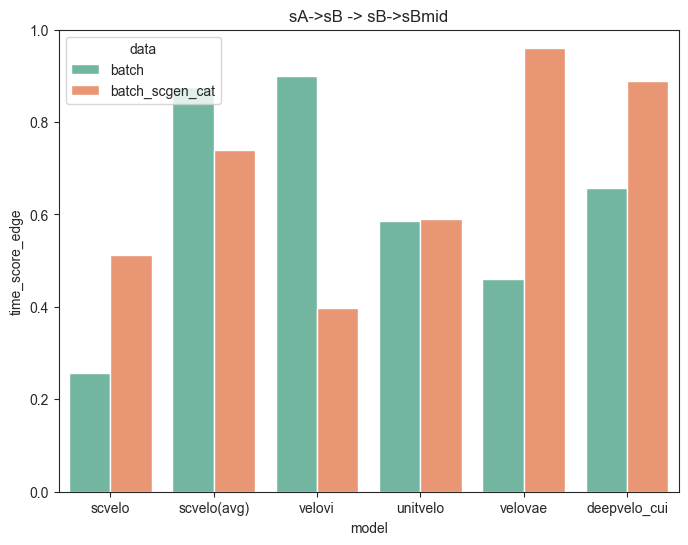

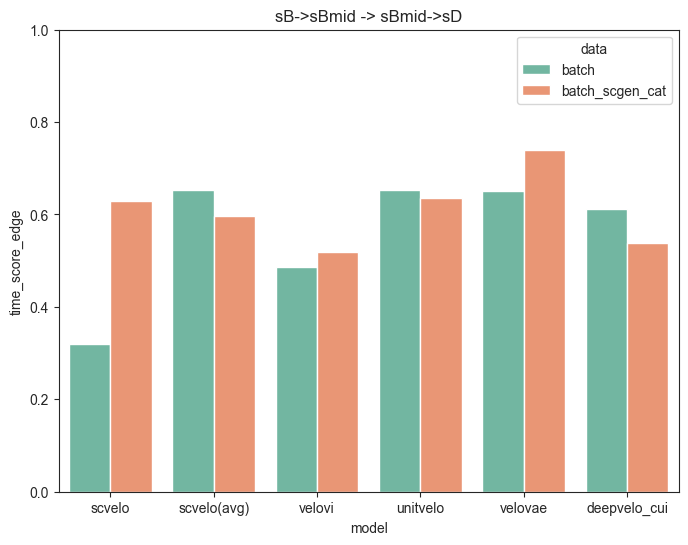

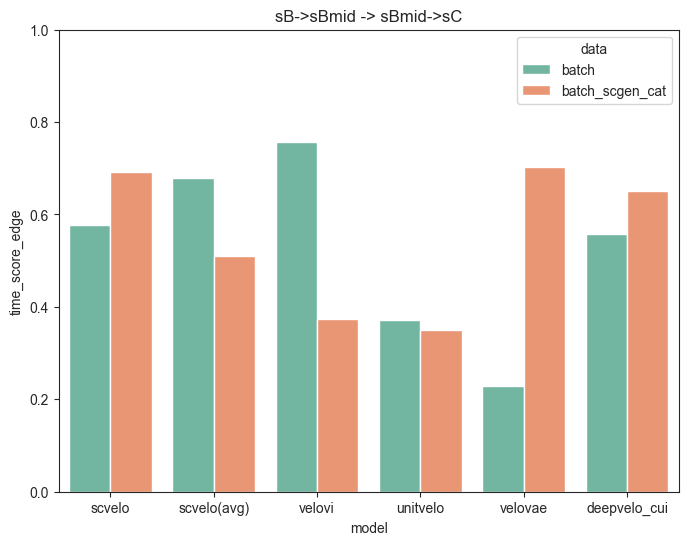

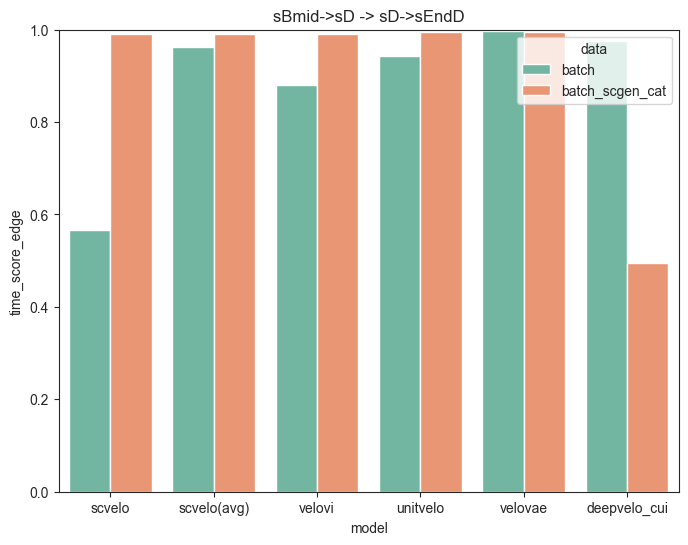

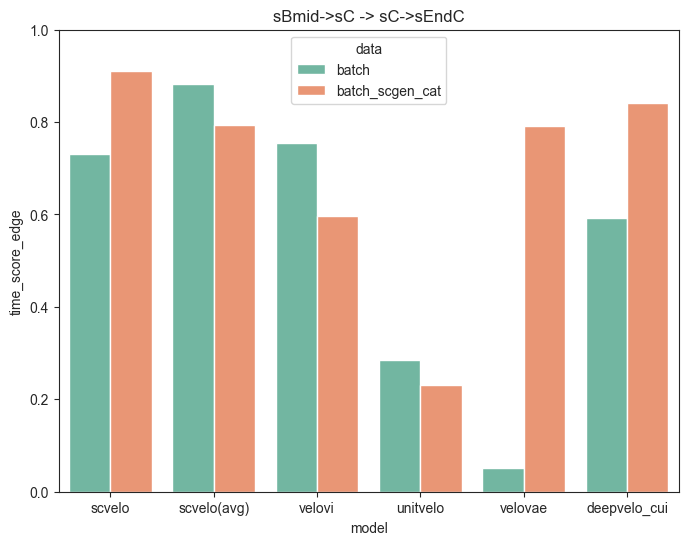

In [11]:
for key, value in results.items():
    df_list = []
    for model, metric in value.items():
        for data, score in metric.items():
            df_list.append([model, data.replace('simulate/', ''), score])
    df = pd.DataFrame(df_list, columns=['model', 'data', metric_name])
    plt.figure(figsize=(8, 6))
    sns.barplot(x='model', y=metric_name, hue='data', data=df, palette='Set2')
    plt.ylim(0, 1)
    plt.title(key)
    plt.savefig(f'{save_dir}/{metric_name}_{key.replace(" -> ", "_").replace(" ", "_").replace("/", "_")}.svg')
    plt.show()